# 1. Importamos las librerías
Corremos esta celda si no tenemos las librerías instaladas.

In [1]:
# pip install requests geopandas matplotlib scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración general de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# 2. Cargamos el DataFrame

In [3]:
df_limpio = pd.read_csv('../data/processed/dataframe_limpio.tsv', sep='\t')

Revisamos si se cargó bien.

In [4]:
df_limpio.head()

,posting_id,sitio,operacion,precio,calle,altura,losa_central,aire_acond,apto_credito,cochera,...,portero,expensas,sobre_avenida,precio_por_m2,segmento_zona,segmento_zona_modelo,log_precio,log_m2,log_precio_m2,amenities_count
0,58757240,zonaprop,alquiler,750000.0,Mansilla,2936.0,0,0,0,0,...,0,300000.0,0,12500.000000,estandar,estandar,13.527830,4.110874,9.433564,5.0
1,58818211,zonaprop,alquiler,1700000.0,Cespedes,2300.0,0,0,0,1,...,0,400000.0,0,14912.280702,estandar,estandar,14.346139,4.744932,9.610007,7.0
2,58564550,zonaprop,alquiler,2500.0,Riobamba,1200.0,0,0,0,1,...,0,1150000.0,0,20.661157,estandar,estandar,7.824446,4.804021,3.075521,9.0
3,58314210,zonaprop,alquiler,1300.0,Pereyra Lucena,2500.0,0,0,0,1,...,0,384500.0,0,19.696970,estandar,estandar,7.170888,4.204693,3.029987,7.0
4,58810878,zonaprop,alquiler,3800.0,Lola Mora,400.0,0,0,0,1,...,0,507000.0,0,32.478632,premium,premium,8.243019,4.770685,3.510907,5.0


In [5]:
df_limpio.shape

(51996, 47)

Hacemos una copia para no modificar el DataFrame original.

In [6]:
df_final = df_limpio.copy()

# 14. KPIs

Definimos los KPIs planteados en la entrega anterior. Los calculamos por barrio y unificamos la moneda a dólares para construir indicadores que engloben toda la base de datos.

In [7]:
from datetime import date
import requests

def obtener_dolar_oficial():
    hoy = date.today().strftime("%Y-%m-%d")

    try:
        url = f"https://estadisticascambiarias.bcra.gob.ar/estadisticascambiarias/v1.0/Cotizaciones/USD?fecha={hoy}"
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        tc = r.json()['results']['detalle'][0]['tipoCotizacion']
        print(f"✓ [BCRA oficial] Dólar oficial al {hoy}: $ {tc:,.2f} ARS/USD")
        return tc
    except Exception as e:
        print(f"✗ BCRA oficial falló: {e}")

    try:
        url = "https://apis.datos.gob.ar/series/api/series/?ids=168.1_T_CAMBIOR_D_0_0_26&limit=1&sort=desc"
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        tc = r.json()['data'][0][1]
        print(f"✓ [datos.gob.ar] Dólar oficial al {hoy}: $ {tc:,.2f} ARS/USD")
        return tc
    except Exception as e:
        print(f"✗ datos.gob.ar falló: {e}")

    try:
        url = "https://dolarapi.com/v1/dolares/oficial"
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        tc = r.json()['venta']
        print(f"✓ [dolarapi.com] Dólar oficial al {hoy}: $ {tc:,.2f} ARS/USD")
        return tc
    except Exception as e:
        print(f"✗ dolarapi.com falló: {e}")

    print("\n⚠ No se pudo obtener el tipo de cambio de ninguna fuente.")
    print("  Ingresalo manualmente en la siguiente línea:")
    return None

TIPO_DE_CAMBIO_USD = obtener_dolar_oficial()

# 2. Convertimos precio y expensas a USD en una copia del DataFrame
df_usd = df_final.copy()
mask_ars = df_usd['moneda'] == 'ars'
df_usd.loc[mask_ars, 'precio']    = df_usd.loc[mask_ars, 'precio']    / TIPO_DE_CAMBIO_USD
df_usd.loc[mask_ars, 'expensas']  = df_usd.loc[mask_ars, 'expensas']  / TIPO_DE_CAMBIO_USD
df_usd['precio_por_m2'] = df_usd['precio'] / df_usd['m2_total']

# 3. DataFrames por tipo de operación (todo en USD)
ventas      = df_usd[df_usd['operacion'] == 'venta'].copy()
alquileres  = df_usd[df_usd['operacion'] == 'alquiler'].copy()
temporarios = df_usd[df_usd['operacion'] == 'alquiler_temporal'].copy()

# 4. Tabla resumen por barrio con la mediana de alquiler y venta (base de los KPIs de rentabilidad)
resumen_barrio = pd.DataFrame({
    'alquiler_mediano': alquileres.groupby('barrio_oficial')['precio'].median(),
    'venta_mediana':    ventas.groupby('barrio_oficial')['precio'].median(),
    'expensas_medianas': alquileres.groupby('barrio_oficial')['expensas'].median(),
}).dropna(subset=['alquiler_mediano', 'venta_mediana'])

resumen_temp = pd.DataFrame({
    'tarifa_mensual_mediana': temporarios.groupby('barrio_oficial')['precio'].median(),
    'venta_mediana':         ventas.groupby('barrio_oficial')['precio'].median(),
    'expensas_medianas':     temporarios.groupby('barrio_oficial')['expensas'].median(),
}).dropna(subset=['tarifa_mensual_mediana', 'venta_mediana'])


✗ BCRA oficial falló: HTTPSConnectionPool(host='estadisticascambiarias.bcra.gob.ar', port=443): Max retries exceeded with url: /estadisticascambiarias/v1.0/Cotizaciones/USD?fecha=2026-06-24 (Caused by NameResolutionError("HTTPSConnection(host='estadisticascambiarias.bcra.gob.ar', port=443): Failed to resolve 'estadisticascambiarias.bcra.gob.ar' ([Errno 11001] getaddrinfo failed)"))
✓ [datos.gob.ar] Dólar oficial al 2026-06-24: $ 1,460.00 ARS/USD


### KPI 1 - Rentabilidad Bruta Alquiler Largo Plazo


In [8]:
# Fórmula: (Alquiler Mensual × 12) / Precio Venta

kpi1 = resumen_barrio.copy()
kpi1['rentabilidad_bruta_pct'] = (
    (kpi1['alquiler_mediano'] * 12) / kpi1['venta_mediana'] * 100
).round(2)
kpi1 = kpi1.sort_values('rentabilidad_bruta_pct', ascending=False)

print("=== KPI 1: Rentabilidad Bruta Largo Plazo (%) — USD ===")
print(kpi1[['alquiler_mediano', 'venta_mediana', 'rentabilidad_bruta_pct']])


=== KPI 1: Rentabilidad Bruta Largo Plazo (%) — USD ===
                   alquiler_mediano  venta_mediana  rentabilidad_bruta_pct
barrio_oficial                                                            
Villa Soldati            530.821918        47000.0                   13.55
Villa Lugano             445.205479        60000.0                    8.90
Nueva Pompeya            479.452055        75000.0                    7.67
Constitucion             445.205479        75000.0                    7.12
Monserrat                500.000000        87000.0                    6.90
Parque Avellaneda        445.205479        78000.0                    6.85
La Boca                  404.109589        73640.0                    6.59
Villa Real               513.698630        95000.0                    6.49
Parque Patricios         445.205479        83000.0                    6.44
San Telmo                513.698630        97500.0                    6.32
Versalles                547.945205       10

### KPI 2 - Recupero de Inversión Largo Plazo


In [9]:
# Fórmula: Precio Venta / (Alquiler Mensual × 12)
# Resultado: años necesarios para recuperar la inversión
# Es el inverso del KPI 1, por lo que reutilizamos el mismo DataFrame.

kpi2 = kpi1.copy()
kpi2['años_recupero'] = (100 / kpi2['rentabilidad_bruta_pct']).round(1)
kpi2 = kpi2.sort_values('años_recupero', ascending=True)

print("=== KPI 2: Recupero de Inversión (años) — USD ===")
print(kpi2[['alquiler_mediano', 'venta_mediana', 'años_recupero']])


=== KPI 2: Recupero de Inversión (años) — USD ===
                   alquiler_mediano  venta_mediana  años_recupero
barrio_oficial                                                   
Villa Soldati            530.821918        47000.0            7.4
Villa Lugano             445.205479        60000.0           11.2
Nueva Pompeya            479.452055        75000.0           13.0
Constitucion             445.205479        75000.0           14.0
Monserrat                500.000000        87000.0           14.5
Parque Avellaneda        445.205479        78000.0           14.6
La Boca                  404.109589        73640.0           15.2
Villa Real               513.698630        95000.0           15.4
Parque Patricios         445.205479        83000.0           15.5
San Telmo                513.698630        97500.0           15.8
Versalles                547.945205       107000.0           16.3
San Nicolas              454.452055        88800.0           16.3
Chacarita                5

### KPI 3 - Precio por metro cuadrado

In [10]:
# Fórmula: Precio / m² (columna precio_por_m2 recalculada en df_usd)

kpi3 = (
    df_usd[df_usd['precio_por_m2'].notna()]
    .groupby(['barrio_oficial', 'operacion'])['precio_por_m2']
    .agg(
        propiedades='count',
        precio_m2_mediano='median',
        precio_m2_promedio='mean'
    )
    .round(0)
    .sort_values(['operacion', 'precio_m2_mediano'], ascending=[True, False])
)

print("=== KPI 3: Precio por m² — USD ===")
print(kpi3)


=== KPI 3: Precio por m² — USD ===
                          propiedades  precio_m2_mediano  precio_m2_promedio
barrio_oficial operacion                                                    
Puerto Madero  alquiler           940               26.0                28.0
Nuñez          alquiler           578               15.0                17.0
Palermo        alquiler          3434               15.0                17.0
Belgrano       alquiler          1508               14.0                16.0
Colegiales     alquiler           267               14.0                17.0
...                               ...                ...                 ...
La Boca        venta              153             1393.0              1543.0
Constitucion   venta              162             1391.0              1450.0
Nueva Pompeya  venta               41             1333.0              1327.0
Villa Lugano   venta              199             1040.0              1323.0
Villa Soldati  venta               18    

### KPI 4 — Rentabilidad Neta Largo Plazo 


In [11]:
# Rentabilidad Neta Largo Plazo: ingreso anual menos expensas del propietario, por barrio.
# Si tiene_expensas == 0, el propietario paga → se descuentan del retorno.
# En alquiler largo plazo la mayoría tiene tiene_expensas == 1, por lo que el resultado
# queda muy similar a la rentabilidad bruta, excepto en los casos donde las paga el propietario.
alquileres_neto = alquileres.copy()
alquileres_neto['ingreso_anual'] = alquileres_neto['precio'] * 12
alquileres_neto['costo_propietario'] = np.where(
    alquileres_neto['tiene_expensas'] == 0,
    alquileres_neto['expensas'] * 12, 0
)
alquileres_neto['retorno_neto'] = alquileres_neto['ingreso_anual'] - alquileres_neto['costo_propietario']

kpi4 = alquileres_neto.groupby('barrio_oficial').agg(
    retorno_neto_mediano=('retorno_neto', 'median'),
    propiedades=('retorno_neto', 'count')
)
kpi4 = kpi4.join(resumen_barrio[['venta_mediana']])
kpi4['rent_neta_lp_pct'] = (kpi4['retorno_neto_mediano'] / kpi4['venta_mediana'] * 100).round(0).astype('Int64')
kpi4 = kpi4.dropna(subset=['rent_neta_lp_pct']).sort_values('rent_neta_lp_pct', ascending=False)

print("=== KPI 4: Rentabilidad Neta Largo Plazo — USD ===")
print(kpi4[['rent_neta_lp_pct', 'propiedades']].to_string())

=== KPI 4: Rentabilidad Neta Largo Plazo — USD ===
                   rent_neta_lp_pct  propiedades
barrio_oficial                                  
Villa Soldati                    14            2
Villa Lugano                      9           77
La Boca                           7           70
Constitucion                      7           90
Nueva Pompeya                     7           17
Monserrat                         7          329
Parque Avellaneda                 7           40
Balvanera                         6          566
Parque Patricios                  6           79
San Nicolas                       6          694
San Cristobal                     6          253
Boedo                             6          143
La Paternal                       6           85
Floresta                          6          134
Chacarita                         6           90
San Telmo                         6          349
Villa Real                        6           19
Versalles         

Para entender verdaderamente cuál es el barrio con mayor renta neta, hay que considerar que no tenemos valores de expensas de todos los barrios. 

### KPI 5 — Precio/m² relativo por barrio


Realizamos el precio del metro cuadrado relativo solo con las propiedades en dolares, debido a que las propiedades en venta en pesos son muy pocas (40)

In [12]:
# Fórmula: Precio/m² de la propiedad / Mediana Precio/m² de su barrio

df_ventas_m2 = ventas[ventas['precio_por_m2'].notna() & (ventas['precio_por_m2'] > 0)].copy()

mediana_por_barrio = df_ventas_m2.groupby('barrio_oficial')['precio_por_m2'].median()
df_ventas_m2['precio_m2_mediano_barrio'] = df_ventas_m2['barrio_oficial'].map(mediana_por_barrio)
df_ventas_m2['precio_m2_relativo'] = (
    df_ventas_m2['precio_por_m2'] / df_ventas_m2['precio_m2_mediano_barrio']
).round(3)

kpi5_barrios = (
    mediana_por_barrio.rename('precio_m2_mediano').reset_index()
    .merge(
        df_ventas_m2.groupby('barrio_oficial').size().rename('propiedades').reset_index(),
        on='barrio_oficial'
    )
    .sort_values('precio_m2_mediano', ascending=False)
    .set_index('barrio_oficial')
)

oportunidades = df_ventas_m2[
    df_ventas_m2['precio_m2_relativo'] < 1
][['barrio_oficial', 'precio', 'm2_total', 'precio_por_m2', 'precio_m2_mediano_barrio', 'precio_m2_relativo']]\
.sort_values('precio_m2_relativo')

print("=== KPI 5: Mediana Precio/m² por Barrio — Ventas USD ===")
print(kpi5_barrios)
print(f"\n=== Propiedades con precio_m2_relativo < 1 (más baratas que su barrio): {len(oportunidades):,} ===")
print(oportunidades.head(20))

=== KPI 5: Mediana Precio/m² por Barrio — Ventas USD ===
                   precio_m2_mediano  propiedades
barrio_oficial                                   
Puerto Madero            5666.666667          575
Nuñez                    3430.769231         1179
Palermo                  3240.740741         4268
Belgrano                 3112.500000         2813
Villa Urquiza            2837.837838         1289
Colegiales               2804.878049          463
Coghlan                  2729.729730          279
Saavedra                 2682.926829          417
Villa Ortuzar            2666.666667          147
Recoleta                 2635.135135         2719
Chacarita                2634.146341          175
Villa Devoto             2602.467949          592
Villa Crespo             2509.165303          936
Parque Chas              2432.432432           87
Villa Luro               2414.285714          488
Caballito                2388.059701         2221
Retiro                   2387.907402       

### KPI 6 — Rentabilidad Bruta Temporario


Utilizamos una tasa de ocupacion del 73%, la correspondiente para los alquileres temporarios entre Febrero de 2025 y Enero de 2026 (fuente Airbtics https://airbtics.com/annual-airbnb-revenue-in-buenos-aires-argentina/)

In [13]:
# Rentabilidad Bruta Temporario: (tarifa mensual × 12) * tasa de ocupacion/ precio de venta
kpi6 = resumen_temp.copy()
kpi6['rent_bruta_temp_pct'] = (kpi6['tarifa_mensual_mediana'] * 12 * 0.73/ kpi6['venta_mediana'] * 100).round(2)
kpi6 = kpi6.sort_values('rent_bruta_temp_pct', ascending=False)

print("=== KPI 6: Rentabilidad Bruta Temporario — USD ===")
print(kpi6[['rent_bruta_temp_pct']].to_string())

=== KPI 6: Rentabilidad Bruta Temporario — USD ===
                   rent_bruta_temp_pct
barrio_oficial                        
Parque Avellaneda                11.23
Nueva Pompeya                    10.80
Villa Luro                        9.53
La Boca                           7.14
Chacarita                         6.77
Constitucion                      6.40
Monserrat                         6.04
Boedo                             5.99
San Nicolas                       5.92
Coghlan                           5.73
Flores                            5.73
San Telmo                         5.71
Villa Pueyrredon                  5.48
Balvanera                         5.40
Agronomia                         5.31
Parque Patricios                  5.06
San Cristobal                     5.06
Colegiales                        5.04
Barracas                          4.91
Monte Castro                      4.78
Villa Crespo                      4.61
Almagro                           4.56
Villa Del Par

### KPI 7 — Índice bruto modalidad óptima

In [14]:
kpi7 = kpi6[['rent_bruta_temp_pct']].join(
    kpi1[['rentabilidad_bruta_pct']].rename(columns={'rentabilidad_bruta_pct': 'rent_bruta_lp_pct'}),
    how='inner')
# Guard: evitar división por cero
kpi7 = kpi7[kpi7['rent_bruta_lp_pct'].notna() & (kpi7['rent_bruta_lp_pct'] != 0)].copy()
kpi7['indice_bruto'] = (kpi7['rent_bruta_temp_pct'] / kpi7['rent_bruta_lp_pct']).round(2)
kpi7['modalidad_optima'] = kpi7.apply(
    lambda r: 'Temporario' if r['rent_bruta_temp_pct'] > r['rent_bruta_lp_pct'] else 'Largo plazo', axis=1)
kpi7 = kpi7.sort_values('indice_bruto', ascending=False)
print("=== KPI 7: Índice Bruto Modalidad Óptima — USD ===")
print(kpi7[['rent_bruta_temp_pct', 'rent_bruta_lp_pct', 'indice_bruto', 'modalidad_optima']].head(20).to_string())


=== KPI 7: Índice Bruto Modalidad Óptima — USD ===
                   rent_bruta_temp_pct  rent_bruta_lp_pct  indice_bruto modalidad_optima
barrio_oficial                                                                          
Villa Luro                        9.53               4.82          1.98       Temporario
Parque Avellaneda                11.23               6.85          1.64       Temporario
Nueva Pompeya                    10.80               7.67          1.41       Temporario
Villa Ortuzar                     4.38               3.79          1.16       Temporario
Chacarita                         6.77               5.98          1.13       Temporario
Coghlan                           5.73               5.06          1.13       Temporario
Flores                            5.73               5.23          1.10       Temporario
Villa Pueyrredon                  5.48               5.07          1.08       Temporario
La Boca                           7.14               6.59  

### KPI 8 — Rentabilidad Neta Temporario

In [15]:
# Rentabilidad Neta Temporario: ingreso anual (precio mensual × 12) menos expensas del propietario.
# En alquiler temporal la mayoría tiene tiene_expensas == 0 (propietario paga por convencion),
# por lo que las expensas sí se descuentan en casi todos los casos.
temporarios_neto = temporarios.copy()

# En df_usd las expensas se convierten a USD solo para propiedades con moneda=='ars'.
# Los temporarios listados en USD tienen el precio ya en USD pero las expensas aún en ARS.
# Las convertimos aquí para que ambas columnas sean comparables.
mask_usd_price = temporarios_neto['moneda'] == 'usd'
if TIPO_DE_CAMBIO_USD and mask_usd_price.any():
    temporarios_neto.loc[mask_usd_price, 'expensas'] = (
        temporarios_neto.loc[mask_usd_price, 'expensas'] / TIPO_DE_CAMBIO_USD
    )

temporarios_neto['ingreso_anual'] = temporarios_neto['precio'] * 12 * 0.73
temporarios_neto['costo_propietario'] = np.where(
    temporarios_neto['tiene_expensas'] == 0,
    temporarios_neto['expensas'] * 12, 0
)
temporarios_neto['retorno_neto'] = temporarios_neto['ingreso_anual'] - temporarios_neto['costo_propietario']

kpi8 = temporarios_neto.groupby('barrio_oficial').agg(
    ingreso_anual_mediano=('ingreso_anual', 'median'),
    costo_propietario_mediano=('costo_propietario', 'median'),
    retorno_neto_mediano=('retorno_neto', 'median'),
    propiedades=('retorno_neto', 'count')
)
kpi8 = kpi8.join(resumen_temp[['venta_mediana']])
kpi8['rent_bruta_temp_pct'] = (kpi8['ingreso_anual_mediano'] / kpi8['venta_mediana'] * 100).round(0).astype('Int64')
kpi8['costo_expensas_pct'] = (kpi8['costo_propietario_mediano'] / kpi8['venta_mediana'] * 100).round(0).astype('Int64')
kpi8['rent_neta_temp_pct'] = (kpi8['retorno_neto_mediano'] / kpi8['venta_mediana'] * 100).round(0).astype('Int64')
kpi8 = kpi8.dropna(subset=['rent_neta_temp_pct']).sort_values('rent_neta_temp_pct', ascending=False)

print("=== KPI 8: Rentabilidad Neta Temporario — USD ===")
print(kpi8[['rent_bruta_temp_pct', 'costo_expensas_pct', 'rent_neta_temp_pct']].head(20).to_string())

=== KPI 8: Rentabilidad Neta Temporario — USD ===
                   rent_bruta_temp_pct  costo_expensas_pct  rent_neta_temp_pct
barrio_oficial                                                                
Nueva Pompeya                       11                   1                   9
Villa Luro                          10                   1                   9
Parque Avellaneda                   11                   4                   8
La Boca                              7                   1                   6
Monserrat                            6                   2                   5
Boedo                                6                   1                   5
San Telmo                            6                   1                   5
Flores                               6                   1                   5
Chacarita                            7                   1                   5
San Nicolas                          6                   1                   5
Co

### KPI 9: Índice Neto Modalidad Óptima 


In [16]:
kpi9 = kpi8[['rent_neta_temp_pct']].join(
    kpi4[['rent_neta_lp_pct']], how='inner')
kpi9 = kpi9[kpi9['rent_neta_lp_pct'].notna() & (kpi9['rent_neta_lp_pct'] != 0)].copy()
kpi9['indice_neto'] = (kpi9['rent_neta_temp_pct'] / kpi9['rent_neta_lp_pct']).round(2)
kpi9['modalidad_optima'] = kpi9.apply(
    lambda r: 'Temporario' if r['rent_neta_temp_pct'] > r['rent_neta_lp_pct'] else 'Largo plazo', axis=1)
kpi9 = kpi9.sort_values('indice_neto', ascending=False)
print("=== KPI 9: Índice Neto Modalidad Óptima — USD ===")
print(kpi9[['rent_neta_temp_pct', 'rent_neta_lp_pct', 'indice_neto', 'modalidad_optima']].head(20).to_string())


=== KPI 9: Índice Neto Modalidad Óptima — USD ===
                   rent_neta_temp_pct  rent_neta_lp_pct  indice_neto modalidad_optima
barrio_oficial                                                                       
Villa Luro                          9                 5          1.8       Temporario
Nueva Pompeya                       9                 7         1.29       Temporario
Parque Avellaneda                   8                 7         1.14       Temporario
Flores                              5                 5          1.0      Largo plazo
Almagro                             4                 4          1.0      Largo plazo
Villa Del Parque                    4                 4          1.0      Largo plazo
Saavedra                            4                 4          1.0      Largo plazo
La Boca                             6                 7         0.86      Largo plazo
San Telmo                           5                 6         0.83      Largo plazo
Boed

### Algunas conclusiones a partir de los KPI:

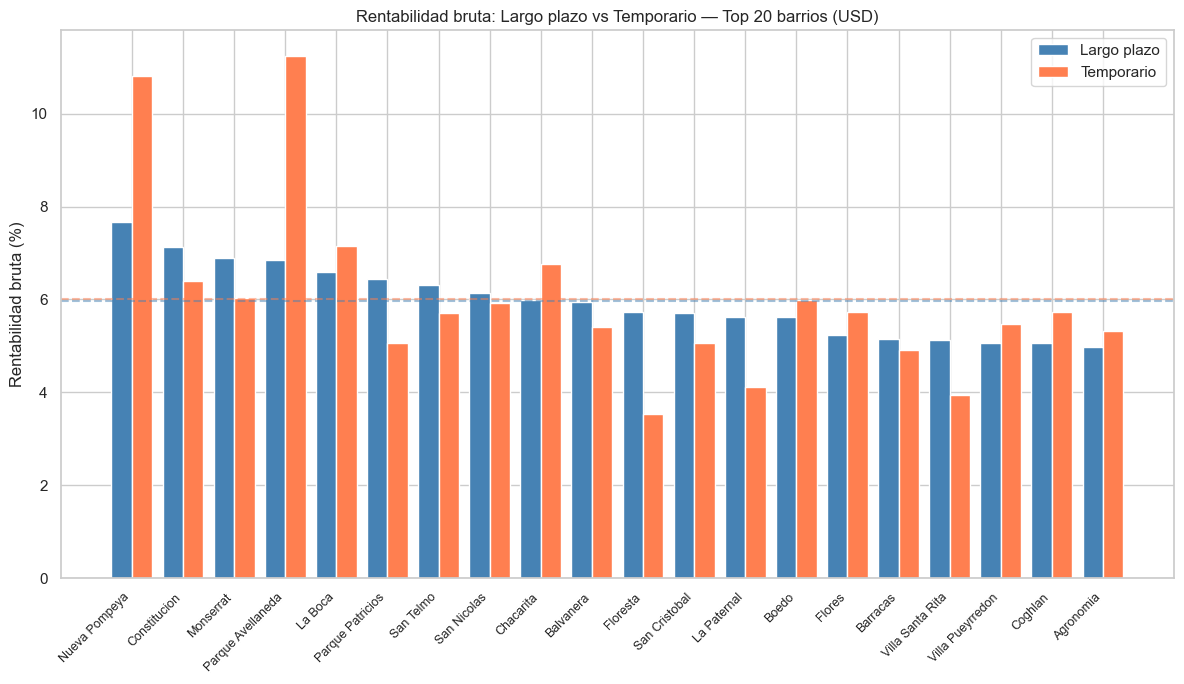

In [17]:
# KPI 1 vs KPI 6: Rentabilidad Bruta LP vs Temporario por barrio
kpi_comparado = kpi1[['rentabilidad_bruta_pct']].join(
    kpi6[['rent_bruta_temp_pct']], how='inner'
).dropna().sort_values('rentabilidad_bruta_pct', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 7))
x = range(len(kpi_comparado))
width = 0.4
ax.bar([i - width/2 for i in x], kpi_comparado['rentabilidad_bruta_pct'],
       width=width, label='Largo plazo', color='steelblue')
ax.bar([i + width/2 for i in x], kpi_comparado['rent_bruta_temp_pct'],
       width=width, label='Temporario', color='coral')
ax.set_xticks(list(x))
ax.set_xticklabels(kpi_comparado.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Rentabilidad bruta (%)')
ax.set_title('Rentabilidad bruta: Largo plazo vs Temporario — Top 20 barrios (USD)', fontsize=12)
ax.legend()
ax.axhline(y=kpi_comparado['rentabilidad_bruta_pct'].mean(),
           color='steelblue', linestyle='--', alpha=0.5, label='Media LP')
ax.axhline(y=kpi_comparado['rent_bruta_temp_pct'].mean(),
           color='coral', linestyle='--', alpha=0.5, label='Media Temp')
plt.tight_layout()
plt.show()

Se puede ver que la diferencia de la rentabilidad bruta difiere significativamente entre barrios sin ninguna predominación fuerte. Sin embargo, para los barrios de 'Nueva Pompeya' y 'Parque Avellaneda', el alquiler temporario tiene una rentabilidad bruta mucho mayor al alquiler a largo plazo.

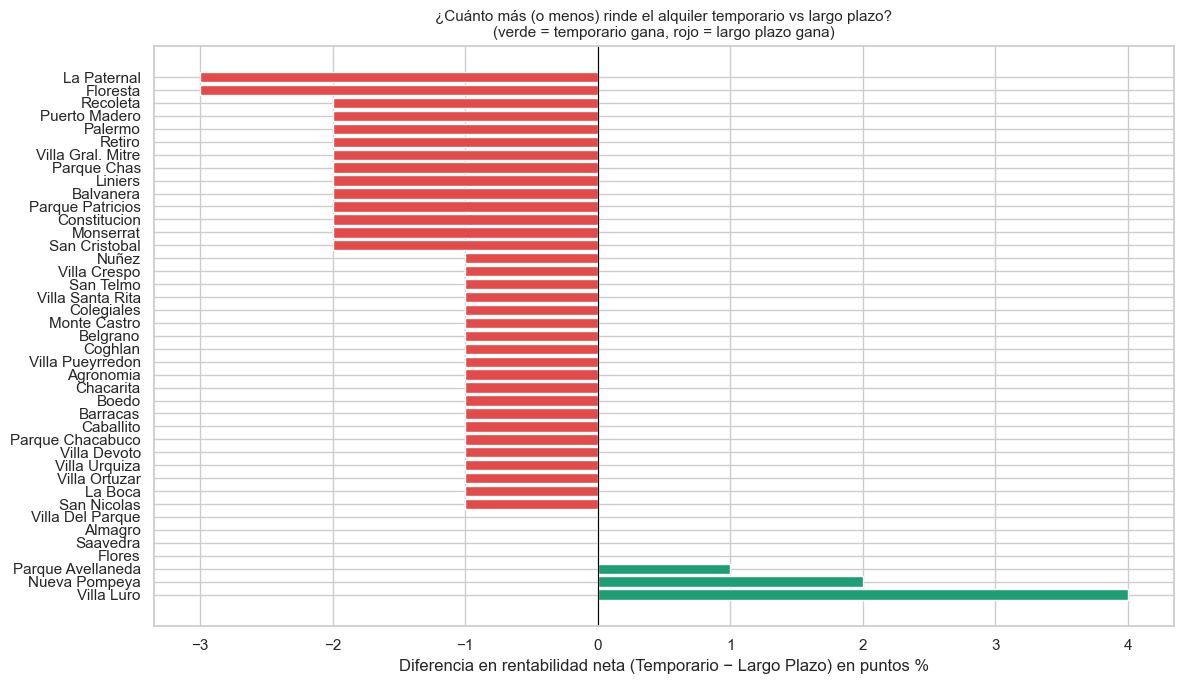

In [18]:
# KPI 4 vs KPI 8: Rentabilidad Neta LP vs Temporario
kpi_neto = kpi4[['rent_neta_lp_pct']].join(
    kpi8[['rent_neta_temp_pct']], how='inner'
).dropna()
kpi_neto['diferencia'] = kpi_neto['rent_neta_temp_pct'] - kpi_neto['rent_neta_lp_pct']
kpi_neto = kpi_neto.sort_values('diferencia', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colores = ['#1D9E75' if d > 0 else '#E24B4A' for d in kpi_neto['diferencia']]
ax.barh(kpi_neto.index, kpi_neto['diferencia'], color=colores, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Diferencia en rentabilidad neta (Temporario − Largo Plazo) en puntos %')
ax.set_title('¿Cuánto más (o menos) rinde el alquiler temporario vs largo plazo?\n(verde = temporario gana, rojo = largo plazo gana)', fontsize=11)
plt.tight_layout()
plt.show()

Ahora, podemos ver la diferencia neta: en este caso, la mayoria de los barrios rinden mejor con alquileres a largo plazo. 

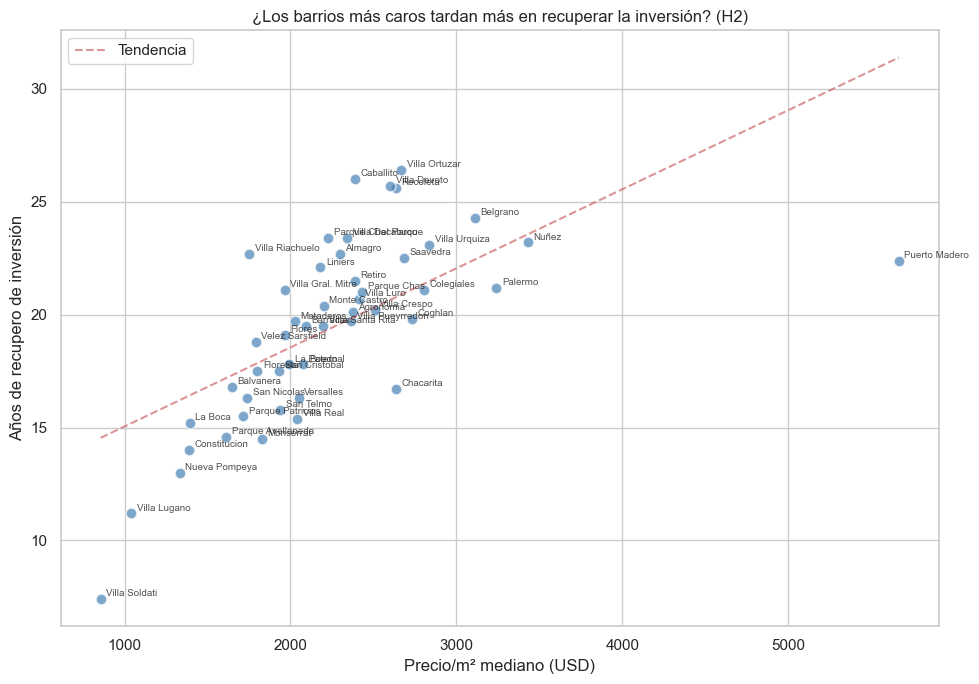

In [19]:
# KPI 2 vs KPI 5: Años de recupero vs precio/m² por barrio
kpi_h2 = kpi2[['años_recupero']].join(
    kpi5_barrios[['precio_m2_mediano']], how='inner'
).dropna()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(kpi_h2['precio_m2_mediano'], kpi_h2['años_recupero'],
           alpha=0.7, s=60, color='steelblue', edgecolors='white')

for barrio, row in kpi_h2.iterrows():
    ax.annotate(barrio, (row['precio_m2_mediano'], row['años_recupero']),
                fontsize=7, alpha=0.8, xytext=(4, 2), textcoords='offset points')

# Línea de tendencia
z = np.polyfit(kpi_h2['precio_m2_mediano'], kpi_h2['años_recupero'], 1)
p = np.poly1d(z)
x_line = np.linspace(kpi_h2['precio_m2_mediano'].min(), kpi_h2['precio_m2_mediano'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', alpha=0.6, linewidth=1.5, label='Tendencia')

ax.set_xlabel('Precio/m² mediano (USD)')
ax.set_ylabel('Años de recupero de inversión')
ax.set_title('¿Los barrios más caros tardan más en recuperar la inversión? (H2)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

Finalmente, podemos ver qué tanto se tarda en recuperar la inversión, segun el barrio. Muchos de los barrios, siguen la linea de tendencia. Pero nuevamente, Puero Madero se destaca por su rápido nivel de recupero, considerando su valor.

In [20]:
# Base: todos los barrios que aparezcan en cualquiera de las tablas
idx_barrios = (
    resumen_barrio.index
    .union(kpi1.index)
    .union(kpi2.index)
    .union(kpi4.index)
    .union(kpi6.index)
    .union(kpi7.index)
    .union(kpi8.index)
    .union(kpi9.index)
    .union(kpi5_barrios.index)
)

kpis_barrio = pd.DataFrame(index=idx_barrios)

# Variables base de mercado
kpis_barrio = kpis_barrio.join(
    resumen_barrio[["venta_mediana", "alquiler_mediano", "expensas_medianas"]],
    how="left"
)

# Si resumen_temp tiene esta columna, la sumamos
kpis_barrio = kpis_barrio.join(
    resumen_temp[["tarifa_mensual_mediana"]],
    how="left"
)

# KPIs largo plazo
kpis_barrio = kpis_barrio.join(
    kpi1[["rentabilidad_bruta_pct"]].rename(columns={
        "rentabilidad_bruta_pct": "rent_bruta_lp_pct"
    }),
    how="left"
)

kpis_barrio = kpis_barrio.join(
    kpi2[["años_recupero"]],
    how="left"
)

kpis_barrio = kpis_barrio.join(
    kpi4[["retorno_neto_mediano", "rent_neta_lp_pct", "propiedades"]].rename(columns={
        "retorno_neto_mediano": "retorno_neto_lp_mediano",
        "propiedades": "n_lp"
    }),
    how="left"
)

# KPI precio por m2
kpis_barrio = kpis_barrio.join(
    kpi5_barrios[["precio_m2_mediano"]],
    how="left"
)

# KPIs temporario
kpis_barrio = kpis_barrio.join(
    kpi6[["rent_bruta_temp_pct"]],
    how="left"
)

kpis_barrio = kpis_barrio.join(
    kpi8[[
        "ingreso_anual_mediano",
        "costo_propietario_mediano",
        "retorno_neto_mediano",
        "costo_expensas_pct",
        "rent_neta_temp_pct",
        "propiedades"
    ]].rename(columns={
        "retorno_neto_mediano": "retorno_neto_temp_mediano",
        "propiedades": "n_temp"
    }),
    how="left"
)

# Comparativos LP vs temporario
kpis_barrio = kpis_barrio.join(
    kpi7[["indice_bruto", "modalidad_optima"]].rename(columns={
        "modalidad_optima": "modalidad_optima_bruta"
    }),
    how="left"
)

kpis_barrio = kpis_barrio.join(
    kpi9[["indice_neto", "modalidad_optima"]].rename(columns={
        "modalidad_optima": "modalidad_optima_neta"
    }),
    how="left"
)

# Dejar barrio como columna
kpis_barrio = kpis_barrio.reset_index().rename(columns={"index": "barrio_oficial"})

# Orden sugerido de columnas
kpis_barrio = kpis_barrio[
    [
        "barrio_oficial",
        "venta_mediana",
        "alquiler_mediano",
        "expensas_medianas",
        "tarifa_mensual_mediana",
        "precio_m2_mediano",
        "rent_bruta_lp_pct",
        "rent_neta_lp_pct",
        "rent_bruta_temp_pct",
        "rent_neta_temp_pct",
        "años_recupero",
        "retorno_neto_lp_mediano",
        "retorno_neto_temp_mediano",
        "ingreso_anual_mediano",
        "costo_propietario_mediano",
        "costo_expensas_pct",
        "indice_bruto",
        "indice_neto",
        "modalidad_optima_bruta",
        "modalidad_optima_neta",
        "n_lp",
        "n_temp",
    ]
]

# Ordenarlo, por ejemplo, por rentabilidad neta temporario
kpis_barrio = kpis_barrio.sort_values("rent_neta_temp_pct", ascending=False)

kpis_barrio.head(20)

,barrio_oficial,venta_mediana,alquiler_mediano,expensas_medianas,tarifa_mensual_mediana,precio_m2_mediano,rent_bruta_lp_pct,rent_neta_lp_pct,rent_bruta_temp_pct,rent_neta_temp_pct,...,retorno_neto_temp_mediano,ingreso_anual_mediano,costo_propietario_mediano,costo_expensas_pct,indice_bruto,indice_neto,modalidad_optima_bruta,modalidad_optima_neta,n_lp,n_temp
19,Nueva Pompeya,75000.0,479.452055,68.493151,925.000000,1333.333333,7.67,7,10.80,9,...,6993.410959,8103.0,1109.589041,1,1.41,1.29,Temporario,Temporario,17,2.0
40,Villa Luro,119450.0,479.452055,89.041096,1300.000000,2414.285714,4.82,5,9.53,9,...,10196.219178,11388.0,1191.780822,1,1.98,1.8,Temporario,Temporario,157,2.0
22,Parque Avellaneda,78000.0,445.205479,75.342466,1000.000000,1612.903226,6.85,7,11.23,8,...,5883.287671,8760.0,2876.712329,4,1.64,1.14,Temporario,Temporario,40,1.0
13,La Boca,73640.0,404.109589,97.602740,600.000000,1393.023256,6.59,7,7.14,6,...,4351.890411,5256.0,986.301370,1,1.08,0.86,Temporario,Largo plazo,70,4.0
17,Monserrat,87000.0,500.000000,130.136986,600.000000,1828.571429,6.90,7,6.04,5,...,4186.438356,5256.0,1479.452055,2,0.88,0.71,Largo plazo,Largo plazo,329,123.0
5,Boedo,95000.0,445.205479,102.739726,650.000000,2076.923077,5.62,6,5.99,5,...,4707.698630,5694.0,986.301370,1,1.07,0.83,Temporario,Largo plazo,143,8.0
32,San Telmo,97500.0,513.698630,138.356164,635.068493,1937.500000,6.32,6,5.71,5,...,4516.273973,5563.2,1068.493151,1,0.90,0.83,Largo plazo,Largo plazo,349,198.0
11,Flores,110000.0,479.452055,102.739726,719.863014,1966.091954,5.23,5,5.73,5,...,4967.794521,6306.0,1232.876712,1,1.10,1.0,Temporario,Largo plazo,547,26.0
7,Chacarita,110000.0,547.945205,136.986301,850.000000,2634.146341,5.98,6,6.77,5,...,5488.767123,7446.0,1438.356164,1,1.13,0.83,Temporario,Largo plazo,90,27.0
31,San Nicolas,88800.0,454.452055,130.136986,600.000000,1739.130435,6.14,6,5.92,5,...,4187.506849,5256.0,1068.493151,1,0.96,0.83,Largo plazo,Largo plazo,694,303.0


# Descarga del dataframe limpio

In [21]:
import os

filename = "dataframe_kpis.tsv"
OUTPUT_DIR = "../data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

filepath = os.path.join(OUTPUT_DIR, filename)
kpis_barrio.to_csv(filepath, sep='\t', index=False, encoding='utf-8-sig')
print(f"\n✅ ¡Éxito! Guardado en: {filepath}")


✅ ¡Éxito! Guardado en: ../data/processed\dataframe_kpis.tsv
